# 06 — Grad-CAM

**Question:** What does the CNN look at to distinguish DMSO from AcDep nuclei?

**Method:** Gradient-weighted Class Activation Mapping (Grad-CAM)
- Forward pass through the CNN
- Compute gradient of the predicted class score with respect to the last conv layer
- Weight each feature map by its gradient → heatmap
- Overlay heatmap on original DAPI patch

**Interpretation:**
- Red/hot zones → CNN focused here to make its decision
- Blue/cold zones → ignored
- If hotspots are at the nuclear periphery → CNN uses shape/boundary
- If hotspots are distributed inside → CNN uses chromatin texture

## Cell 1 — Parameters

In [ ]:
PATCHES_PATH    = "patches.npz"
MODEL_PATH      = "best_model_binary.pt"
OUTPUT_DIR      = "gradcam"

# How many example nuclei to show per class
N_EXAMPLES = 8

RANDOM_SEED = 42

print("Parameters set ✓")

Parameters set ✓


## Cell 2 — Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"Device: {DEVICE}")
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Device: mps


## Cell 3 — Rebuild CNN architecture (must match 05_cnn_classifier exactly)

In [4]:
class NucleusCNN(nn.Module):
    def __init__(self, n_classes, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

print("Architecture defined ✓")

Architecture defined ✓


## Cell 4 — Load patches and model

In [5]:
# Load patches
data    = np.load(PATCHES_PATH, allow_pickle=True)
patches = data['patches'].astype(np.float32)
labels  = data['labels']

# Fix shape if needed
if patches.shape[1] != 1:
    patches = patches.squeeze()[:, np.newaxis, :, :]
print(f"Patches shape: {patches.shape}")

# Keep only binary classes
mask    = np.isin(labels, ['DMSO', 'AcDep'])
patches = patches[mask]
labels  = labels[mask]

# Encode labels
le      = LabelEncoder()
y       = le.fit_transform(labels)
classes = le.classes_
print(f"Classes: {classes}")  # AcDep=0, DMSO=1
print(f"Patches per class: { {c: (labels==c).sum() for c in classes} }")

# Load model
model = NucleusCNN(n_classes=2, dropout=0.5).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded ✓")

Patches shape: (356, 1, 64, 64)
Classes: ['AcDep' 'DMSO']
Patches per class: {np.str_('AcDep'): np.int64(148), np.str_('DMSO'): np.int64(102)}
Model loaded ✓


## Cell 5 — Grad-CAM implementation

In [6]:
class GradCAM:
    """
    Grad-CAM for a single convolutional layer.

    How it works:
    1. Register hooks on the target layer to capture:
       - activations (forward pass output of that layer)
       - gradients (backprop gradient flowing into that layer)
    2. Forward pass → get class scores
    3. Backward pass on the target class score
    4. Global average pool the gradients → one weight per feature map
    5. Weighted sum of feature maps → raw CAM
    6. ReLU → keep only positive contributions
    7. Resize to input image size

    Why the last conv layer?
    It has the highest-level spatial features — it's the last place
    where spatial information and semantic information coexist.
    After the flatten + FC layers, spatial information is gone.
    """

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        self.gradients    = None

        # Register forward hook — captures feature maps
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        # Register backward hook — captures gradients
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        """
        Generate Grad-CAM heatmap for one input patch.

        Args:
            input_tensor : (1, 1, 64, 64) tensor
            class_idx    : which class to explain (None = predicted class)

        Returns:
            cam          : (64, 64) numpy array, values in [0, 1]
            pred_class   : predicted class index
            confidence   : softmax probability of predicted class
        """
        self.model.zero_grad()

        # Forward pass
        output = self.model(input_tensor)          # (1, n_classes)
        probs  = torch.softmax(output, dim=1)

        pred_class = output.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()

        if class_idx is None:
            class_idx = pred_class

        # Backward pass on target class score
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Global average pool gradients → weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

        # Weighted sum of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)

        # ReLU — keep only positive contributions
        cam = F.relu(cam)

        # Resize to input size (64×64)
        cam = F.interpolate(cam, size=(64, 64), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam, pred_class, confidence

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


# Attach Grad-CAM to the last conv layer (block3, index 0 = Conv2d)
gradcam = GradCAM(model, target_layer=model.block3[0])
print("Grad-CAM attached to: model.block3[0] (last Conv2d layer) ✓")

Grad-CAM attached to: model.block3[0] (last Conv2d layer) ✓


## Cell 6 — Generate and visualize Grad-CAM maps

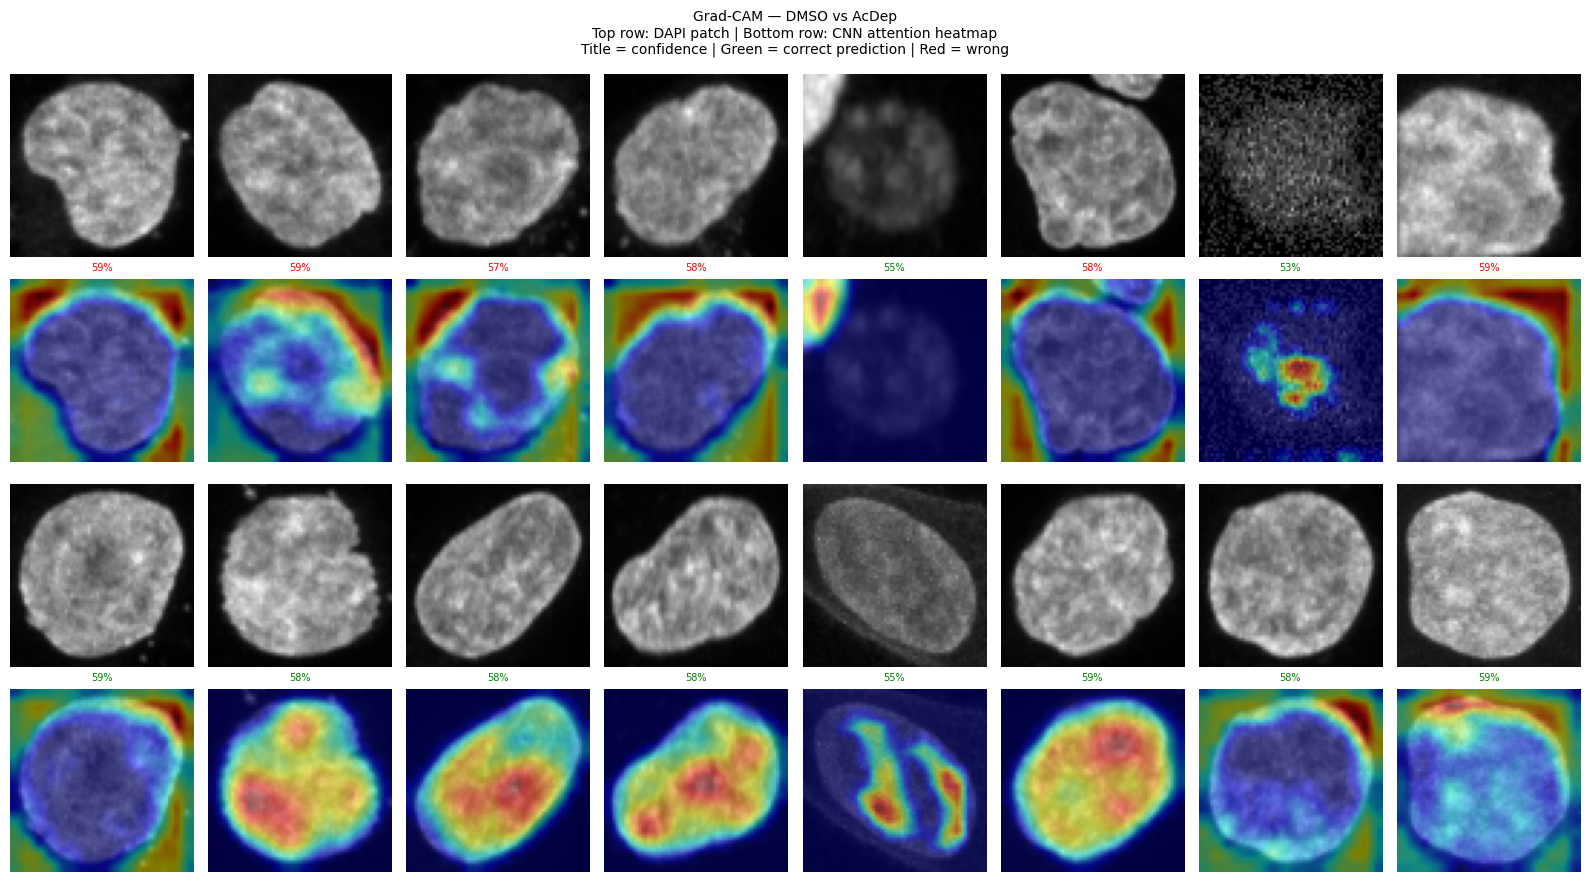

Saved gradcam_examples.png ✓


In [7]:
def overlay_gradcam(patch, cam, alpha=0.5):
    """
    Overlay Grad-CAM heatmap on DAPI patch.
    patch : (64, 64) float array [0,1]
    cam   : (64, 64) float array [0,1]
    Returns RGB image (64, 64, 3)
    """
    # DAPI → grayscale RGB
    dapi_rgb = np.stack([patch, patch, patch], axis=-1)

    # CAM → colormap (jet: blue=low, red=high)
    heatmap = cm.jet(cam)[:, :, :3]   # (64, 64, 3), drop alpha channel

    # Blend
    overlay = (1 - alpha) * dapi_rgb + alpha * heatmap
    return np.clip(overlay, 0, 1)


rng = np.random.default_rng(RANDOM_SEED)

fig, axes = plt.subplots(
    len(classes) * 2, N_EXAMPLES,
    figsize=(N_EXAMPLES * 2, len(classes) * 4 + 1)
)

for class_row, cls in enumerate(classes):
    cls_idx  = le.transform([cls])[0]
    cls_mask = labels == cls
    indices  = np.where(cls_mask)[0]
    chosen   = rng.choice(indices, size=min(N_EXAMPLES, len(indices)), replace=False)

    raw_row = class_row * 2       # row for raw patches
    cam_row = class_row * 2 + 1   # row for grad-cam overlays

    for col, idx in enumerate(chosen):
        patch  = patches[idx, 0]   # (64, 64)
        tensor = torch.tensor(patches[idx:idx+1], dtype=torch.float32).to(DEVICE)
        tensor.requires_grad_(True)

        # Generate Grad-CAM for the TRUE class
        cam, pred_cls, conf = gradcam.generate(tensor, class_idx=cls_idx)
        overlay = overlay_gradcam(patch, cam)

        correct = (pred_cls == cls_idx)
        border_color = 'green' if correct else 'red'

        # Raw patch
        axes[raw_row, col].imshow(patch, cmap='gray', vmin=0, vmax=1)
        axes[raw_row, col].axis('off')
        if col == 0:
            axes[raw_row, col].set_ylabel(f'{cls}\nDAPI', fontsize=9,
                                           rotation=0, labelpad=55, va='center')

        # Grad-CAM overlay
        axes[cam_row, col].imshow(overlay)
        axes[cam_row, col].axis('off')
        # Color title green if correctly predicted, red if wrong
        axes[cam_row, col].set_title(
            f"{conf:.0%}",
            fontsize=7,
            color=border_color
        )
        if col == 0:
            axes[cam_row, col].set_ylabel(f'{cls}\nGrad-CAM', fontsize=9,
                                           rotation=0, labelpad=55, va='center')

plt.suptitle(
    "Grad-CAM — DMSO vs AcDep\n"
    "Top row: DAPI patch | Bottom row: CNN attention heatmap\n"
    "Title = confidence | Green = correct prediction | Red = wrong",
    fontsize=10
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/gradcam_examples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved gradcam_examples.png ✓")

## Cell 7 — Average Grad-CAM per class
Average heatmap across all nuclei of each class.
This shows the **typical attention pattern** for DMSO vs AcDep.

AcDep: averaged 148 Grad-CAM maps
DMSO: averaged 102 Grad-CAM maps


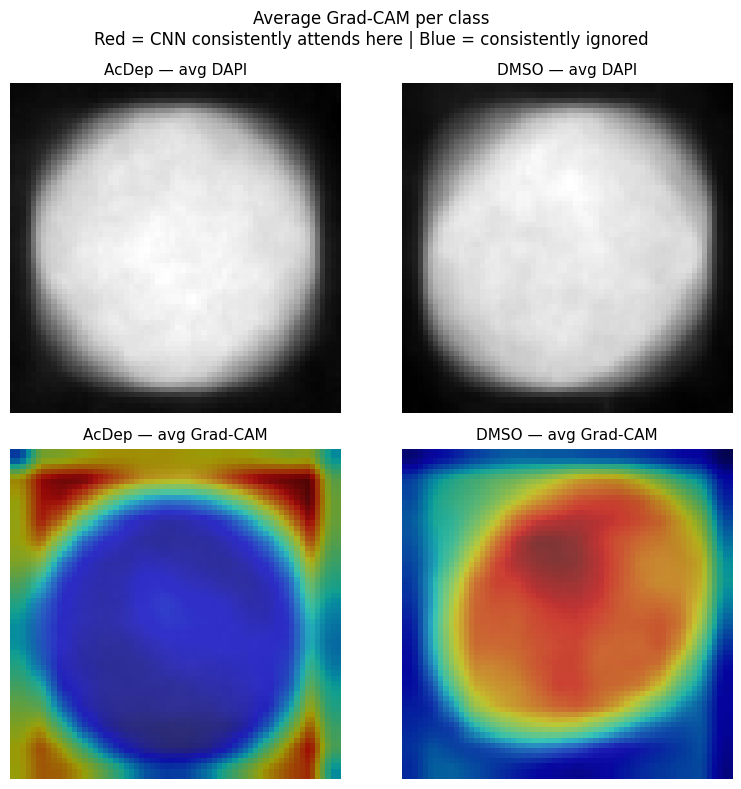

Saved gradcam_average.png ✓
Hooks removed ✓


In [8]:
avg_cams   = {}
avg_patches = {}

for cls in classes:
    cls_idx  = le.transform([cls])[0]
    cls_mask = labels == cls
    cls_patches = patches[cls_mask]

    cams = []
    for i in range(len(cls_patches)):
        tensor = torch.tensor(cls_patches[i:i+1], dtype=torch.float32).to(DEVICE)
        cam, _, _ = gradcam.generate(tensor, class_idx=cls_idx)
        cams.append(cam)

    avg_cams[cls]    = np.mean(cams, axis=0)       # (64, 64)
    avg_patches[cls] = cls_patches[:, 0].mean(axis=0)  # (64, 64)
    print(f"{cls}: averaged {len(cams)} Grad-CAM maps")

# Plot
fig, axes = plt.subplots(2, len(classes), figsize=(len(classes) * 4, 8))

for col, cls in enumerate(classes):
    # Average DAPI patch
    axes[0, col].imshow(avg_patches[cls], cmap='gray')
    axes[0, col].set_title(f'{cls} — avg DAPI', fontsize=11)
    axes[0, col].axis('off')

    # Average Grad-CAM overlay
    cam_norm = avg_cams[cls]
    if cam_norm.max() > 0:
        cam_norm = (cam_norm - cam_norm.min()) / (cam_norm.max() - cam_norm.min())
    overlay = overlay_gradcam(avg_patches[cls], cam_norm, alpha=0.6)
    axes[1, col].imshow(overlay)
    axes[1, col].set_title(f'{cls} — avg Grad-CAM', fontsize=11)
    axes[1, col].axis('off')

plt.suptitle(
    "Average Grad-CAM per class\n"
    "Red = CNN consistently attends here | Blue = consistently ignored",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/gradcam_average.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved gradcam_average.png ✓")

gradcam.remove_hooks()
print("Hooks removed ✓")